# Marco de Trabajo del Gobierno del Dato: Objetivos y Roles en Accion

**Bloque:** Gobierno del Dato y Estrategia  

En la sesion anterior exploramos que es el gobierno del dato, por que es necesario y quienes son los actores principales (CDO, Data Owner, Data Steward, Data Custodian, etc.). Hoy damos el paso del "que" al "como": vamos a trabajar con las herramientas que permiten poner en marcha un programa de gobierno del dato real.

Al terminar esta sesion sereis capaces de:

- Identificar los objetivos estrategicos que justifican un programa de gobierno del dato.
- Construir una matriz RACI que asigne responsabilidades concretas a los roles ya conocidos.
- Catalogar las politicas que componen un marco de gobierno.
- Evaluar el nivel de madurez de una organizacion en gobierno del dato.

Trabajaremos con un caso ficticio, **DataMart España**, una cadena de retail con 120 tiendas fisicas y una tienda online en pleno proceso de digitalizacion. Actualmente no tienen un programa formal de gobierno del dato, y nos han encargado disenar su marco de trabajo.

## 1. Preparacion del entorno

Importamos las librerias que usaremos. Son las mismas que ya conoceis de sesiones anteriores: pandas para estructurar datos en tablas, numpy para calculos numericos y matplotlib para visualizacion.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Entorno listo.")

Entorno listo.


## 2. Marcos de referencia: de la teoria a la practica

Antes de construir nada, conviene saber que no partimos de cero. Existen marcos de referencia reconocidos internacionalmente que las organizaciones usan como punto de partida para disenar su programa de gobierno del dato. Los dos mas relevantes son:

- **DAMA-DMBOK (Data Management Body of Knowledge):** publicado por la DAMA International, es la referencia mas completa. Define 11 areas de gestion de datos (calidad, metadatos, seguridad, arquitectura, etc.) y proporciona un vocabulario comun para toda la industria. Es como el "manual de instrucciones" del dato.

- **DGI (Data Governance Institute) Framework:** mas centrado en la gobernanza como funcion organizativa. Se enfoca en definir roles, politicas, estandares y metricas. Es mas practico y orientado a la implementacion que DAMA.

En la practica, la mayoria de organizaciones no adoptan un marco al 100%. Toman elementos de varios y los adaptan a su realidad. Eso es exactamente lo que vamos a hacer hoy con DataMart Espana: construir un marco pragmatico que combine lo mejor de ambos enfoques.

La estructura tipica de un marco de gobierno del dato tiene cuatro componentes fundamentales:

1. **Objetivos estrategicos** -- el "para que" del programa.
2. **Roles y responsabilidades** -- el "quien hace que" (lo formalizamos con la matriz RACI).
3. **Politicas y procesos** -- las "reglas del juego".
4. **Metricas de madurez** -- el "como sabemos que avanzamos".

## 3. Objetivos estrategicos del gobierno del dato

Todo programa de gobierno del dato debe responder a una pregunta basica: "para que estamos haciendo esto?". Sin objetivos claros, el programa se convierte en burocracia sin proposito.

Los objetivos estrategicos se agrupan tipicamente en cuatro pilares:

- **Calidad de datos:** garantizar que los datos sean correctos, completos, consistentes y oportunos. Un dato de mala calidad genera decisiones erroneas.
- **Cumplimiento normativo:** asegurar que la organizacion cumple con regulaciones como el RGPD, la LOPDGDD o normativas sectoriales. El incumplimiento puede suponer multas millonarias.
- **Generacion de valor:** convertir los datos en un activo estrategico que impulse ingresos, reduzca costes o mejore la experiencia del cliente.
- **Confianza organizacional:** lograr que todos los departamentos confien en los datos que usan para tomar decisiones, eliminando la cultura del "cada uno tiene su Excel".

Vamos a modelar los objetivos concretos de DataMart Espana. Observad que cada objetivo tiene una metrica asociada: un objetivo sin metrica no se puede gestionar.

In [2]:
# Definimos los objetivos estrategicos de DataMart Espana.
# Cada objetivo incluye el pilar al que pertenece, una descripcion concreta,
# la metrica con la que se medira el progreso y el estado actual.

objetivos = pd.DataFrame({
    "Pilar": [
        "Calidad", "Calidad",
        "Cumplimiento", "Cumplimiento",
        "Valor", "Valor",
        "Confianza", "Confianza"
    ],
    "Objetivo": [
        "Reducir duplicados en base de clientes",
        "Estandarizar formatos de producto entre tiendas y online",
        "Cumplir con RGPD en datos de clientes",
        "Implementar politica de retencion de datos",
        "Crear vista unica del cliente (360)",
        "Habilitar analisis predictivo de demanda",
        "Definir fuente unica de verdad para ventas",
        "Eliminar informes contradictorios entre departamentos"
    ],
    "Metrica": [
        "% duplicados < 2%",
        "% campos estandarizados > 95%",
        "Audit RGPD sin hallazgos criticos",
        "100% datos con fecha de expiracion asignada",
        "Cobertura de atributos cliente > 80%",
        "Modelo predictivo con MAPE < 15%",
        "1 dashboard oficial de ventas adoptado por todos",
        "0 discrepancias en reporting mensual"
    ],
    "Estado_actual": [
        "No medido", "En progreso",
        "Parcial", "No iniciado",
        "No iniciado", "No iniciado",
        "En progreso", "Critico"
    ]
})

print("Objetivos estrategicos de DataMart Espana:")
print("=" * 60)
objetivos

Objetivos estrategicos de DataMart Espana:


,Pilar,Objetivo,Metrica,Estado_actual
0,Calidad,Reducir duplicados en base de clientes,% duplicados < 2%,No medido
1,Calidad,Estandarizar formatos de producto entre tienda...,% campos estandarizados > 95%,En progreso
2,Cumplimiento,Cumplir con RGPD en datos de clientes,Audit RGPD sin hallazgos criticos,Parcial
3,Cumplimiento,Implementar politica de retencion de datos,100% datos con fecha de expiracion asignada,No iniciado
4,Valor,Crear vista unica del cliente (360),Cobertura de atributos cliente > 80%,No iniciado
5,Valor,Habilitar analisis predictivo de demanda,Modelo predictivo con MAPE < 15%,No iniciado
6,Confianza,Definir fuente unica de verdad para ventas,1 dashboard oficial de ventas adoptado por todos,En progreso
7,Confianza,Eliminar informes contradictorios entre depart...,0 discrepancias en reporting mensual,Critico


Visualicemos como se distribuyen los objetivos por pilar y cual es su estado actual. Este tipo de vista panoramica es util para presentar el programa a la direccion de la empresa y priorizar esfuerzos.

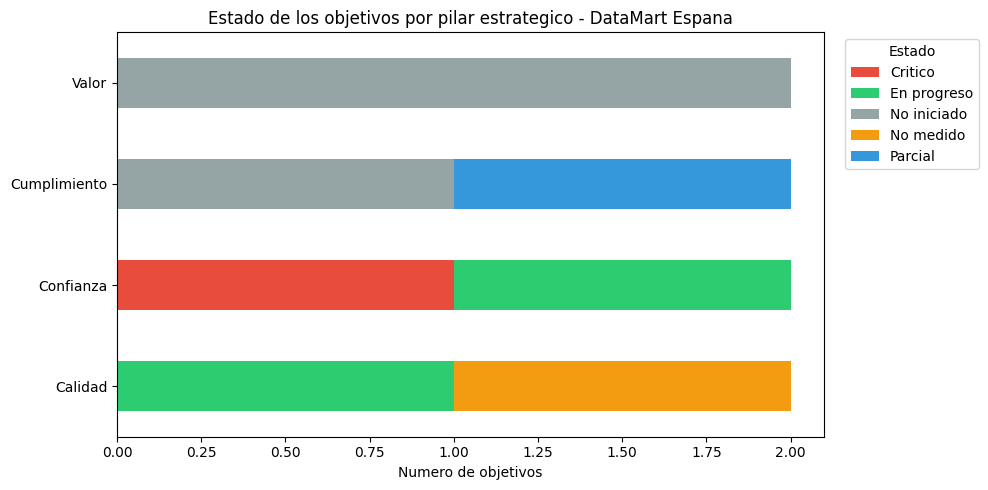

In [3]:
# Contamos cuantos objetivos hay en cada combinacion pilar-estado.
# Esto nos da una foto rapida de donde estamos.

resumen = objetivos.groupby(["Pilar", "Estado_actual"]).size().unstack(fill_value=0)

# Definimos colores que representen intuitivamente cada estado
colores = {
    "Critico": "#e74c3c",
    "No iniciado": "#95a5a6",
    "No medido": "#f39c12",
    "Parcial": "#3498db",
    "En progreso": "#2ecc71"
}

fig, ax = plt.subplots(figsize=(10, 5))
resumen.plot(kind="barh", stacked=True, ax=ax,
             color=[colores.get(c, "#bdc3c7") for c in resumen.columns])

ax.set_xlabel("Numero de objetivos")
ax.set_ylabel("")
ax.set_title("Estado de los objetivos por pilar estrategico - DataMart Espana")
ax.legend(title="Estado", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 4. Matriz RACI: asignar responsabilidades

Conocer los roles del gobierno del dato (como vimos en la sesion anterior) no es suficiente. Necesitamos definir exactamente que hace cada rol en cada actividad. Para eso usamos la **matriz RACI**, una herramienta estandar de gestion que asigna cuatro niveles de participacion:

- **R (Responsible / Responsable):** quien ejecuta la tarea. Hace el trabajo.
- **A (Accountable / Aprobador):** quien rinde cuentas del resultado. Solo puede haber uno por actividad.
- **C (Consulted / Consultado):** a quien se pide opinion antes de actuar. Comunicacion bidireccional.
- **I (Informed / Informado):** a quien se notifica del resultado. Comunicacion unidireccional.

Reglas importantes de una buena matriz RACI:

1. Cada fila (actividad) debe tener exactamente un "A".
2. Cada fila debe tener al menos un "R".
3. Demasiados "C" en una fila indica un proceso lento por exceso de consultas.
4. Si un rol no tiene ninguna "R" ni "A" en toda la matriz, su participacion en el programa es cuestionable.

Vamos a construir la matriz RACI de DataMart Espana. Usaremos los roles que ya conoceis: CDO (Chief Data Officer), Data Owner, Data Steward, Data Custodian y Comite de Gobierno.

In [4]:
# Construimos la matriz RACI como un DataFrame.
# Las filas son actividades de gobierno del dato.
# Las columnas son los roles.
# Cada celda contiene R, A, C o I.

actividades = [
    "Definir politicas de datos",
    "Validar calidad de datos",
    "Gestionar accesos y permisos",
    "Resolver incidencias de datos",
    "Reportar metricas de gobierno",
    "Aprobar cambios en esquemas de datos",
    "Formar a usuarios en buenas practicas",
    "Auditar cumplimiento normativo"
]

roles = ["CDO", "Data Owner", "Data Steward", "Data Custodian", "Comite Gobierno"]

# Cada lista representa una fila (actividad) con la asignacion RACI por rol
asignaciones = [
    ["A", "C", "R", "I", "C"],  # Definir politicas
    ["I", "A", "R", "C", "I"],  # Validar calidad
    ["I", "A", "C", "R", "I"],  # Gestionar accesos
    ["C", "A", "R", "R", "I"],  # Resolver incidencias
    ["A", "C", "R", "I", "I"],  # Reportar metricas
    ["A", "C", "I", "R", "C"],  # Aprobar cambios esquemas
    ["A", "I", "R", "I", "C"],  # Formar usuarios
    ["A", "C", "R", "C", "I"],  # Auditar cumplimiento
]

raci = pd.DataFrame(asignaciones, index=actividades, columns=roles)
raci.index.name = "Actividad"

print("Matriz RACI de Gobierno del Dato - DataMart Espana")
print("=" * 60)
raci

Matriz RACI de Gobierno del Dato - DataMart Espana


,CDO,Data Owner,Data Steward,Data Custodian,Comite Gobierno
Actividad,,,,,
Definir politicas de datos,A,C,R,I,C
Validar calidad de datos,I,A,R,C,I
Gestionar accesos y permisos,I,A,C,R,I
Resolver incidencias de datos,C,A,R,R,I
Reportar metricas de gobierno,A,C,R,I,I
Aprobar cambios en esquemas de datos,A,C,I,R,C
Formar a usuarios en buenas practicas,A,I,R,I,C
Auditar cumplimiento normativo,A,C,R,C,I


La matriz es funcional pero poco visual. Vamos a aplicar formato condicional con los estilos de pandas para que sea mas facil interpretar de un vistazo quien hace que. Esto es algo que hariais tambien en un entorno profesional al presentar la RACI a direccion.

In [5]:
# Funcion que asigna un color de fondo segun el valor RACI.
# Usamos colores suaves que permitan leer el texto negro encima.

def colorear_raci(val):
    colores = {
        "R": "background-color: #3498db; color: white; font-weight: bold;",
        "A": "background-color: #e74c3c; color: white; font-weight: bold;",
        "C": "background-color: #f39c12; color: white; font-weight: bold;",
        "I": "background-color: #95a5a6; color: white;"
    }
    return colores.get(val, "")

# Aplicamos el estilo. applymap aplica la funcion celda a celda.
raci_styled = raci.style.applymap(colorear_raci)
raci_styled

AttributeError: The '.style' accessor requires jinja2

Ahora validemos que nuestra matriz RACI cumple las reglas basicas. En un entorno profesional, una RACI mal construida genera confusion en lugar de claridad. Vamos a comprobar automaticamente las dos reglas fundamentales: que cada actividad tenga exactamente un "A" y al menos un "R".

In [6]:
# Validacion automatica de la matriz RACI.
# Recorremos cada actividad y comprobamos las reglas.

print("Validacion de la matriz RACI")
print("=" * 60)

errores = 0

for actividad in raci.index:
    fila = raci.loc[actividad]
    n_accountable = (fila == "A").sum()
    n_responsible = (fila == "R").sum()

    if n_accountable != 1:
        print(f"  ERROR: '{actividad}' tiene {n_accountable} 'A' (debe ser exactamente 1)")
        errores += 1
    if n_responsible < 1:
        print(f"  ERROR: '{actividad}' no tiene ningun 'R'")
        errores += 1

if errores == 0:
    print("  Todas las actividades cumplen las reglas RACI.")

# Analisis adicional: carga por rol
print()
print("Carga de trabajo por rol:")
print("-" * 40)
for rol in roles:
    col = raci[rol]
    n_r = (col == "R").sum()
    n_a = (col == "A").sum()
    print(f"  {rol:20s} -> {n_r} tareas como Responsable, {n_a} como Aprobador")

Validacion de la matriz RACI
  Todas las actividades cumplen las reglas RACI.

Carga de trabajo por rol:
----------------------------------------
  CDO                  -> 0 tareas como Responsable, 5 como Aprobador
  Data Owner           -> 0 tareas como Responsable, 3 como Aprobador
  Data Steward         -> 6 tareas como Responsable, 0 como Aprobador
  Data Custodian       -> 3 tareas como Responsable, 0 como Aprobador
  Comite Gobierno      -> 0 tareas como Responsable, 0 como Aprobador


### Ejercicio: Ampliar la matriz RACI

La matriz anterior cubre actividades genericas. Pero DataMart Espana tiene necesidades especificas de su negocio. Anadid al menos dos actividades nuevas relacionadas con su contexto retail y asignad los niveles RACI.

Algunas ideas (no teneis que usar estas, podeis inventar las vuestras):

- Validar datos de inventario entre tiendas fisicas y online
- Gestionar el consentimiento de clientes del programa de fidelizacion
- Definir el catalogo de datos maestros de producto

Completad el codigo de abajo:

In [ ]:
# EJERCICIO: Anadid nuevas actividades a la matriz RACI.
# Descomentad y completad las lineas siguientes.

# nuevas_actividades = {
#     "Validar inventario tiendas vs online": ["?", "?", "?", "?", "?"],
#     "Vuestra actividad aqui":               ["?", "?", "?", "?", "?"],
# }
#
# nuevas_df = pd.DataFrame(nuevas_actividades, index=roles).T
# nuevas_df.index.name = "Actividad"
# raci_ampliada = pd.concat([raci, nuevas_df])
# raci_ampliada.style.applymap(colorear_raci)

## 5. Politicas y procesos: las reglas del juego

Un marco de gobierno sin politicas es como un partido de futbol sin reglas: cada uno juega a su manera. Las politicas definen los estandares, procedimientos y limites que todos deben seguir al trabajar con datos.

Los tipos de politicas mas habituales en un programa de gobierno del dato son:

- **Acceso:** quien puede ver y modificar que datos, bajo que condiciones.
- **Calidad:** que estandares deben cumplir los datos (formatos, completitud, frescura).
- **Retencion:** cuanto tiempo se conservan los datos y cuando se eliminan.
- **Privacidad:** como se protegen los datos personales (directamente ligado al RGPD).
- **Linaje:** como se documenta el origen, transformaciones y destino de cada dato.

Cada politica tiene un ciclo de vida: se define, se aprueba, se implementa, se monitoriza y se revisa periodicamente. No son documentos estaticos que se crean una vez y se olvidan.

Vamos a catalogar las politicas que DataMart Espana necesita implementar:

In [7]:
# Catalogo de politicas de gobierno del dato para DataMart Espana.
# Cada politica tiene un ambito, un responsable (rol que la gestiona),
# una frecuencia de revision y su estado actual.

politicas = pd.DataFrame({
    "Politica": [
        "Control de acceso a datos de clientes",
        "Estandar de calidad de datos de producto",
        "Retencion de datos transaccionales",
        "Privacidad y consentimiento RGPD",
        "Linaje de datos de ventas",
        "Clasificacion de datos por sensibilidad",
        "Gestion de datos maestros (MDM)",
        "Backup y recuperacion de datos criticos"
    ],
    "Tipo": [
        "Acceso", "Calidad", "Retencion", "Privacidad",
        "Linaje", "Acceso", "Calidad", "Acceso"
    ],
    "Responsable": [
        "Data Custodian", "Data Steward", "Data Owner", "CDO",
        "Data Steward", "CDO", "Data Owner", "Data Custodian"
    ],
    "Frecuencia_revision": [
        "Trimestral", "Mensual", "Anual", "Semestral",
        "Trimestral", "Anual", "Trimestral", "Mensual"
    ],
    "Estado": [
        "Borrador", "No iniciada", "No iniciada", "Borrador",
        "No iniciada", "No iniciada", "No iniciada", "Vigente"
    ]
})

print("Catalogo de politicas - DataMart Espana")
print("=" * 60)
politicas

Catalogo de politicas - DataMart Espana


,Politica,Tipo,Responsable,Frecuencia_revision,Estado
0,Control de acceso a datos de clientes,Acceso,Data Custodian,Trimestral,Borrador
1,Estandar de calidad de datos de producto,Calidad,Data Steward,Mensual,No iniciada
2,Retencion de datos transaccionales,Retencion,Data Owner,Anual,No iniciada
3,Privacidad y consentimiento RGPD,Privacidad,CDO,Semestral,Borrador
4,Linaje de datos de ventas,Linaje,Data Steward,Trimestral,No iniciada
5,Clasificacion de datos por sensibilidad,Acceso,CDO,Anual,No iniciada
6,Gestion de datos maestros (MDM),Calidad,Data Owner,Trimestral,No iniciada
7,Backup y recuperacion de datos criticos,Acceso,Data Custodian,Mensual,Vigente


Analicemos la cobertura y el estado del catalogo de politicas. Esto nos da una idea de cuanto trabajo queda por hacer y donde estan los gaps mas criticos.

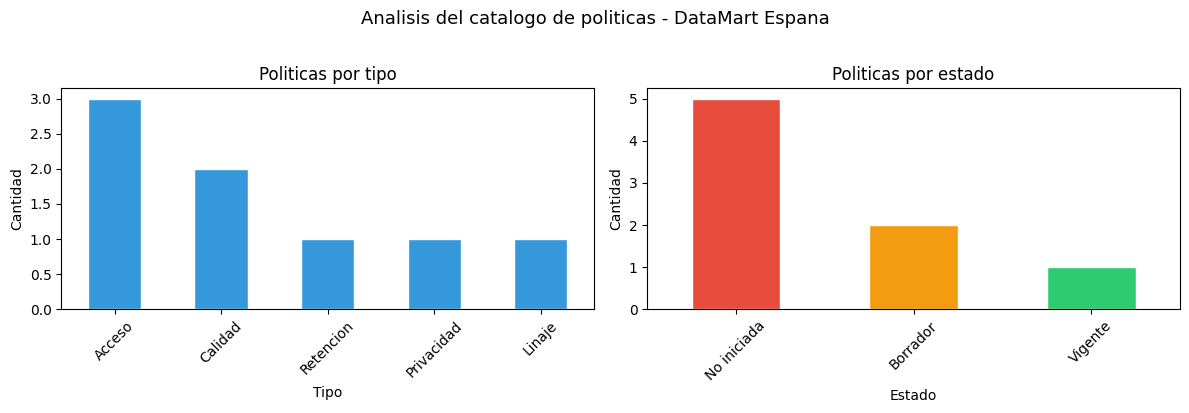

Solo 1 de 8 politicas estan vigentes (12%).
Esto indica que el programa de gobierno esta en una fase muy temprana.


In [8]:
# Analisis del estado de las politicas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Grafico 1: Distribucion por tipo
politicas["Tipo"].value_counts().plot(
    kind="bar", ax=axes[0], color="#3498db", edgecolor="white"
)
axes[0].set_title("Politicas por tipo")
axes[0].set_ylabel("Cantidad")
axes[0].tick_params(axis="x", rotation=45)

# Grafico 2: Distribucion por estado
colores_estado = {"Vigente": "#2ecc71", "Borrador": "#f39c12", "No iniciada": "#e74c3c"}
estado_counts = politicas["Estado"].value_counts()
estado_counts.plot(
    kind="bar", ax=axes[1],
    color=[colores_estado.get(e, "#bdc3c7") for e in estado_counts.index],
    edgecolor="white"
)
axes[1].set_title("Politicas por estado")
axes[1].set_ylabel("Cantidad")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Analisis del catalogo de politicas - DataMart Espana", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Resumen textual
vigentes = (politicas["Estado"] == "Vigente").sum()
total = len(politicas)
print(f"Solo {vigentes} de {total} politicas estan vigentes ({vigentes/total*100:.0f}%).")
print("Esto indica que el programa de gobierno esta en una fase muy temprana.")

### Ejercicio: Identificar politicas que faltan

Revisad el catalogo anterior. Pensad en el contexto de DataMart Espana (retail, 120 tiendas, ecommerce, programa de fidelizacion) y responded:

1. Hay algun tipo de politica que no esta representado y deberia estarlo?
2. Hay algun area del negocio (por ejemplo, logistica, RRHH, marketing) que genera datos criticos y no tiene politica asignada?
3. La frecuencia de revision de la politica de privacidad RGPD (semestral), os parece adecuada? Por que?

## 6. Evaluacion de madurez: donde estamos y adonde vamos

Un error comun al implementar gobierno del dato es intentar llegar a la excelencia de golpe. Los modelos de madurez nos ayudan a evaluar donde esta la organizacion hoy y a planificar una evolucion realista por fases.

El modelo mas utilizado se inspira en CMMI (Capability Maturity Model Integration) y define cinco niveles:

| Nivel | Nombre | Descripcion |
|-------|--------|-------------|
| 1 | Inicial | Los datos se gestionan de forma ad hoc. No hay procesos definidos. Cada departamento hace lo suyo. |
| 2 | Repetible | Existen algunos procesos basicos, pero dependen de personas concretas. Si esa persona se va, el proceso se pierde. |
| 3 | Definido | Los procesos estan documentados y son consistentes. Hay roles asignados formalmente. |
| 4 | Gestionado | Se miden y monitorizan los procesos con metricas. Se toman decisiones basadas en datos sobre los propios datos. |
| 5 | Optimizado | Mejora continua. Los procesos se ajustan proactivamente. La organizacion trata los datos como un activo estrategico. |

Vamos a evaluar a DataMart Espana en cinco dimensiones clave y a visualizar su perfil de madurez con un grafico radar.

In [9]:
# Evaluacion de madurez de DataMart Espana.
# Puntuamos cada dimension en una escala de 1 a 5.
# Estas puntuaciones son el resultado de una "auditoria" ficticia.

madurez = pd.DataFrame({
    "Dimension": ["Personas", "Procesos", "Tecnologia", "Datos", "Cultura"],
    "Puntuacion": [2, 1, 3, 2, 1],
    "Justificacion": [
        "Hay un responsable de datos informal, pero no hay roles formales definidos",
        "No existen procesos documentados de gestion de datos",
        "Usan SQL Server y un ERP, pero sin herramientas de calidad o catalogacion",
        "Datos dispersos en silos, sin inventario ni diccionario de datos",
        "Los datos se ven como un subproducto, no como un activo"
    ]
})

print("Evaluacion de madurez - DataMart Espana")
print("=" * 60)
for _, row in madurez.iterrows():
    barra = "+" * row["Puntuacion"] + "-" * (5 - row["Puntuacion"])
    print(f"  {row['Dimension']:12s} [{barra}] {row['Puntuacion']}/5")
    print(f"               {row['Justificacion']}")
    print()

media = madurez["Puntuacion"].mean()
print(f"Puntuacion media: {media:.1f}/5 -> Nivel: {'Inicial' if media < 2 else 'Repetible' if media < 3 else 'Definido'}")

Evaluacion de madurez - DataMart Espana
  Personas     [++---] 2/5
               Hay un responsable de datos informal, pero no hay roles formales definidos

  Procesos     [+----] 1/5
               No existen procesos documentados de gestion de datos

  Tecnologia   [+++--] 3/5
               Usan SQL Server y un ERP, pero sin herramientas de calidad o catalogacion

  Datos        [++---] 2/5
               Datos dispersos en silos, sin inventario ni diccionario de datos

  Cultura      [+----] 1/5
               Los datos se ven como un subproducto, no como un activo

Puntuacion media: 1.8/5 -> Nivel: Inicial


El grafico radar (o grafico de arana) es la forma estandar de visualizar un perfil de madurez. Permite ver de un vistazo las fortalezas y debilidades de la organizacion, y comparar el estado actual con el estado objetivo.

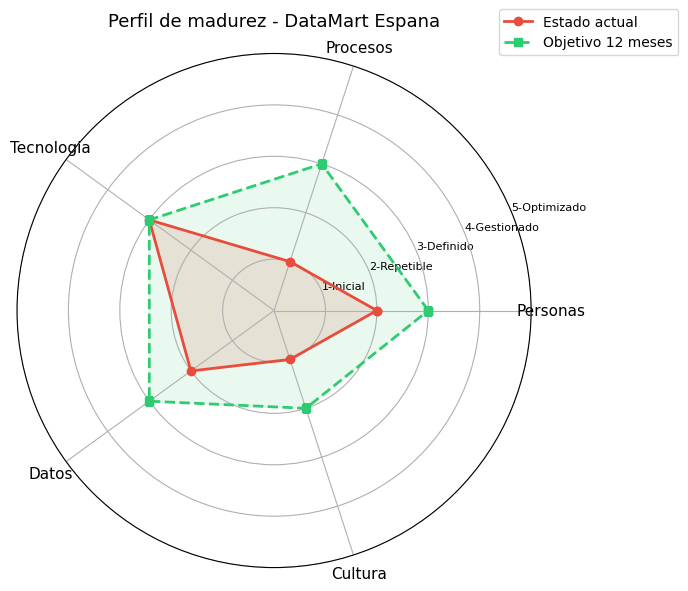

In [10]:
# Grafico radar de madurez.
# Anadimos un "objetivo" a 12 meses para ver la brecha.

dimensiones = madurez["Dimension"].tolist()
valores_actual = madurez["Puntuacion"].tolist()
valores_objetivo = [3, 3, 3, 3, 2]  # Objetivo realista a 12 meses

# Para cerrar el poligono, repetimos el primer valor al final
dimensiones_cerrado = dimensiones + [dimensiones[0]]
actual_cerrado = valores_actual + [valores_actual[0]]
objetivo_cerrado = valores_objetivo + [valores_objetivo[0]]

# Calculamos los angulos para cada dimension
angulos = np.linspace(0, 2 * np.pi, len(dimensiones), endpoint=False).tolist()
angulos += angulos[:1]  # Cerramos el circulo

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

# Dibujamos el estado actual y el objetivo
ax.plot(angulos, actual_cerrado, "o-", linewidth=2, label="Estado actual", color="#e74c3c")
ax.fill(angulos, actual_cerrado, alpha=0.15, color="#e74c3c")

ax.plot(angulos, objetivo_cerrado, "s--", linewidth=2, label="Objetivo 12 meses", color="#2ecc71")
ax.fill(angulos, objetivo_cerrado, alpha=0.10, color="#2ecc71")

# Configuramos las etiquetas y los limites
ax.set_xticks(angulos[:-1])
ax.set_xticklabels(dimensiones, fontsize=11)
ax.set_ylim(0, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(["1-Inicial", "2-Repetible", "3-Definido", "4-Gestionado", "5-Optimizado"],
                   fontsize=8)

ax.set_title("Perfil de madurez - DataMart Espana", fontsize=13, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

A partir del radar podemos identificar las brechas y priorizar acciones. La dimension con mayor brecha (diferencia entre actual y objetivo) es la que necesita mas atencion inmediata.

In [11]:
# Calculamos la brecha por dimension y generamos un plan de accion priorizado

madurez["Objetivo_12m"] = valores_objetivo
madurez["Brecha"] = madurez["Objetivo_12m"] - madurez["Puntuacion"]

# Ordenamos por brecha descendente (mayor prioridad primero)
plan = madurez.sort_values("Brecha", ascending=False)[["Dimension", "Puntuacion", "Objetivo_12m", "Brecha"]]

print("Plan de accion priorizado por brecha")
print("=" * 60)
for i, (_, row) in enumerate(plan.iterrows(), 1):
    print(f"  {i}. {row['Dimension']:12s} | Actual: {row['Puntuacion']} | Objetivo: {row['Objetivo_12m']} | Brecha: {row['Brecha']}")

print()
print("Las dimensiones de Procesos y Cultura son las que requieren mayor esfuerzo.")
print("Esto es habitual: la tecnologia suele estar mas avanzada que la organizacion.")

Plan de accion priorizado por brecha
  1. Procesos     | Actual: 1 | Objetivo: 3 | Brecha: 2
  2. Personas     | Actual: 2 | Objetivo: 3 | Brecha: 1
  3. Datos        | Actual: 2 | Objetivo: 3 | Brecha: 1
  4. Cultura      | Actual: 1 | Objetivo: 2 | Brecha: 1
  5. Tecnologia   | Actual: 3 | Objetivo: 3 | Brecha: 0

Las dimensiones de Procesos y Cultura son las que requieren mayor esfuerzo.
Esto es habitual: la tecnologia suele estar mas avanzada que la organizacion.


## 7. Reflexion y discusion

Preguntas para debatir en grupo:

1. Si fuerais el CDO recien contratado de DataMart Espana, por cual de los cuatro pilares estrategicos empezariais? Por que?

2. En la matriz RACI, el Data Steward tiene muchas "R" (tareas de ejecucion). Es sostenible a largo plazo? Que pasaria si la empresa solo tiene un Data Steward para 120 tiendas?

3. Solo 1 de 8 politicas esta vigente. Es esto alarmante o esperable en una empresa que empieza su programa de gobierno?

4. El objetivo de madurez a 12 meses es llegar a nivel 3 en la mayoria de dimensiones. Os parece realista? Que recursos (personas, tecnologia, presupuesto) harian falta?

5. Que conexion veis entre lo que hemos trabajado hoy (marco de trabajo) y lo que veremos en la proxima sesion (calidad, metadatos y privacidad)?

## Proximos pasos

Hoy hemos construido el esqueleto del marco de gobierno de DataMart Espana: objetivos, responsabilidades (RACI), politicas y nivel de madurez.

En la **proxima sesion** profundizaremos en tres de las areas mas operativas del gobierno del dato:

- **Calidad de datos:** como definir reglas de calidad, medirlas y automatizarlas.
- **Metadatos:** el "dato sobre el dato", fundamental para que la organizacion sepa que datos tiene y donde estan.
- **Privacidad:** RGPD en la practica, anonimizacion, seudonimizacion y gestion del consentimiento.

Y en la **sesion 5** pondras todo junto en un reto guiado: disenar un plan de gobierno del dato completo para un caso real.